In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("C:\\Users\\user\\Desktop\\Vani_Linear_Regression\\work_from_home_burnout_dataset.csv")
df

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low
...,...,...,...,...,...,...,...,...,...,...,...
1795,180,Weekend,6.33,8.16,0,4,0,5.59,73.5,31.91,Low
1796,180,Weekend,4.70,7.88,0,4,0,6.69,89.8,26.30,Low
1797,180,Weekend,3.92,6.39,2,1,0,6.77,74.6,34.07,Low
1798,180,Weekday,8.93,11.11,2,5,0,8.28,74.6,38.14,Low


In [4]:
df['day_type'].unique()

array(['Weekday', 'Weekend'], dtype=object)

In [5]:
def daysTollumber(day):
    if day == "Weekday":
        return 0
    else:
        return 1



In [6]:
df['day_type']= df['day_type'].apply(daysTollumber)
df

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,0,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,1,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,1,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,0,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,1,6.97,9.83,1,2,0,5.85,67.1,51.61,Low
...,...,...,...,...,...,...,...,...,...,...,...
1795,180,1,6.33,8.16,0,4,0,5.59,73.5,31.91,Low
1796,180,1,4.70,7.88,0,4,0,6.69,89.8,26.30,Low
1797,180,1,3.92,6.39,2,1,0,6.77,74.6,34.07,Low
1798,180,0,8.93,11.11,2,5,0,8.28,74.6,38.14,Low


In [7]:
df['burnout_risk'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [8]:
def riskToNumber(risk):
    if risk == 'Low':
        return 0
    elif risk == 'Medium':
        return 1
    else:
        return 2


In [9]:
df['burnout_risk']= df['burnout_risk'].apply(riskToNumber)
df

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,0,9.59,11.86,4,2,0,7.55,91.2,19.17,0
1,1,1,7.38,10.33,4,1,0,6.69,82.0,29.70,0
2,1,1,6.31,8.92,1,2,0,8.87,80.6,32.93,0
3,1,0,8.34,10.70,4,1,1,8.13,70.0,45.47,0
4,1,1,6.97,9.83,1,2,0,5.85,67.1,51.61,0
...,...,...,...,...,...,...,...,...,...,...,...
1795,180,1,6.33,8.16,0,4,0,5.59,73.5,31.91,0
1796,180,1,4.70,7.88,0,4,0,6.69,89.8,26.30,0
1797,180,1,3.92,6.39,2,1,0,6.77,74.6,34.07,0
1798,180,0,8.93,11.11,2,5,0,8.28,74.6,38.14,0


In [10]:
df.columns

Index(['user_id', 'day_type', 'work_hours', 'screen_time_hours',
       'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours',
       'task_completion_rate', 'burnout_score', 'burnout_risk'],
      dtype='object')

In [11]:
X = df[['user_id', 'day_type', 'work_hours', 'screen_time_hours','meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours','task_completion_rate']]
y = df['burnout_score']

In [12]:
X

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate
0,1,0,9.59,11.86,4,2,0,7.55,91.2
1,1,1,7.38,10.33,4,1,0,6.69,82.0
2,1,1,6.31,8.92,1,2,0,8.87,80.6
3,1,0,8.34,10.70,4,1,1,8.13,70.0
4,1,1,6.97,9.83,1,2,0,5.85,67.1
...,...,...,...,...,...,...,...,...,...
1795,180,1,6.33,8.16,0,4,0,5.59,73.5
1796,180,1,4.70,7.88,0,4,0,6.69,89.8
1797,180,1,3.92,6.39,2,1,0,6.77,74.6
1798,180,0,8.93,11.11,2,5,0,8.28,74.6


In [13]:
y

0       19.17
1       29.70
2       32.93
3       45.47
4       51.61
        ...  
1795    31.91
1796    26.30
1797    34.07
1798    38.14
1799    40.76
Name: burnout_score, Length: 1800, dtype: float64

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y)

In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
model = LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred = model.predict(X_test)
y_pred

array([-3.54345578, 32.3434009 , 53.02115144, 65.30244938, 26.95799265,
       24.10508768, 29.58525268, 48.35669452, 38.6084942 , 50.38121662,
       93.32997761, 25.67229718, 42.24922645, 40.01627573, 29.19720307,
       37.14427984, 17.59471245, 54.98124051, 38.04360491, 34.78884036,
       38.83516556, 30.68802402, 94.13336061, 29.87069661, 30.7379043 ,
       61.24967103, 21.38392964, 59.16735888, 49.25805962, 20.83653824,
       10.55969059, 42.4066164 , 93.41488918, 17.58862473, 22.46650943,
       18.84474393, 34.25000611, 93.68330388, 21.61178981, 89.73140218,
       28.86359697, 20.83687296, 56.77228696, 82.08942956, 43.29781576,
       19.3390279 ,  8.10274109, 87.93090816, 54.13539196, 71.46148596,
       22.7438356 , 13.20990579, 56.08182855, 39.31963473, 65.69136454,
       30.97442731, 20.53447849, 32.28210016, 53.8792684 , 29.42854246,
       44.79141766, 39.84785232,  9.24608458, 58.91224417,  2.39349045,
       26.34647859, 47.3048314 , 58.28900015, 94.33288109, 23.53

In [19]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [20]:
print(mean_absolute_error(y_test,y_pred))

5.125122611773858


In [21]:
print(mean_squared_error(y_test,y_pred))

41.68836426173972


In [22]:
print(root_mean_squared_error(y_test,y_pred))

6.456652713422003


In [23]:
print(r2_score(y_test,y_pred))

0.9242158765521838


In [24]:
print(y_test[:10])

20       3.78
1005    30.79
227     50.73
636     75.96
653     34.61
1187    28.12
916     29.53
332     45.52
773     34.11
1666    41.36
Name: burnout_score, dtype: float64


In [25]:
print(y_pred[:10])

[-3.54345578 32.3434009  53.02115144 65.30244938 26.95799265 24.10508768
 29.58525268 48.35669452 38.6084942  50.38121662]


In [26]:
print(pd.Series(y_pred[:10]))

0    -3.543456
1    32.343401
2    53.021151
3    65.302449
4    26.957993
5    24.105088
6    29.585253
7    48.356695
8    38.608494
9    50.381217
dtype: float64


In [27]:
df

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,0,9.59,11.86,4,2,0,7.55,91.2,19.17,0
1,1,1,7.38,10.33,4,1,0,6.69,82.0,29.70,0
2,1,1,6.31,8.92,1,2,0,8.87,80.6,32.93,0
3,1,0,8.34,10.70,4,1,1,8.13,70.0,45.47,0
4,1,1,6.97,9.83,1,2,0,5.85,67.1,51.61,0
...,...,...,...,...,...,...,...,...,...,...,...
1795,180,1,6.33,8.16,0,4,0,5.59,73.5,31.91,0
1796,180,1,4.70,7.88,0,4,0,6.69,89.8,26.30,0
1797,180,1,3.92,6.39,2,1,0,6.77,74.6,34.07,0
1798,180,0,8.93,11.11,2,5,0,8.28,74.6,38.14,0


In [28]:
df.columns

Index(['user_id', 'day_type', 'work_hours', 'screen_time_hours',
       'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours',
       'task_completion_rate', 'burnout_score', 'burnout_risk'],
      dtype='object')

In [29]:
X = df[['user_id', 'day_type', 'work_hours', 'screen_time_hours','meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours','task_completion_rate', 'burnout_score']]
y = df['burnout_risk']

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y)

In [32]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [33]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,

In [34]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [35]:
accuracy_score(y_test,y_pred)



0.9977777777777778

In [36]:
precision_score(y_test,y_pred,average="macro")

0.9942528735632185

In [37]:
recall_score(y_test,y_pred,average='macro')

0.8888888888888888

In [38]:
f1_score(y_test,y_pred,average= 'macro')

0.9304347826086957

In [39]:
confusion_matrix(y_test,y_pred)

array([[390,   0,   0],
       [  0,  57,   0],
       [  0,   1,   2]])

[Text(0.4, 0.8333333333333334, 'x[9] <= 69.965\ngini = 0.269\nsamples = 1350\nvalue = [1137, 196, 17]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 1137\nvalue = [1137, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[9] <= 110.715\ngini = 0.147\nsamples = 213\nvalue = [0, 196, 17]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 196\nvalue = [0, 196, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 17\nvalue = [0, 0, 17]')]

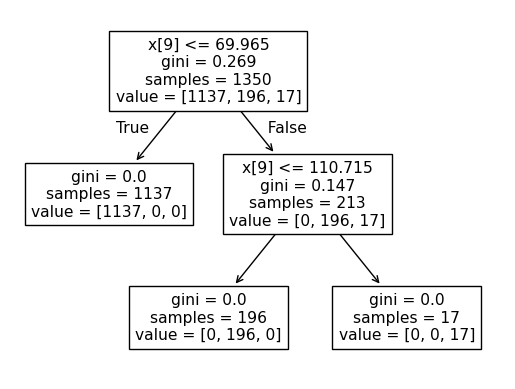

In [40]:
from sklearn.tree import plot_tree
plot_tree(model)